# Calibrate single camera

The aim of this calibration is to:
1. Assess the distortion of the cameras
2. function between X,Y,Z coordinates of the world and X,Y coordinates of the frame

## Plan
1. Open the video recorded with a camera
2. Detect corners of the chessboard
4. Calibrate and return points
5. Join the calibration info from previous steps and perform stereo calibration

In [6]:
import numpy as np
import cv2 as cv
import time
import matplotlib.pyplot as plt
from utils import DLT, fit_plane,transform_to_custom_frame
import time

In [7]:
# Video name
Nvideo = 18
VideoName = './Videos/09_07_2026/pcte'+str(Nvideo)

VideoA = VideoName+'A.avi'
VideoB = VideoName+'B.avi'
print(VideoA)

./Videos/09_07_2026/pcte18A.avi


## 1. Define function to calibrate two cameras

In [8]:
def draw_lines(lines,image):
    lines_list =[]
    line_image = np.zeros_like(image)
    for points in lines:
      # Extracted points nested in the list
        x1,y1,x2,y2=points[0]
        # Draw the lines joing the points
        # On the original image
        #plt.plot([x1,x2],[y1,y2],color='red')
        cv.line(line_image,(x1,y1),(x2,y2),(0,255,0),2)
        # Maintain a simples lookup list for points
        #lines_list.append([(x1,y1),(x2,y2)])
    
    return line_image


In [9]:

def detect_grid_corners(img, roi_top_frac=0.60, tophat_kernel=15,
                         min_component_area=150, min_line_length=35,
                         max_line_gap=20, hough_threshold=25,
                         horizontal_angle_thresh=15, angle_merge_deg=8,
                         dist_merge_px=15, min_merged_line_length=80,
                         roi_polygon=None):
    """
    Detect corners formed by 2 (roughly) horizontal boundary lines and
    several near-vertical/diagonal divider lines painted on a floor
    (e.g. a marked walking lane / gait mat), as seen at an angle.

    Strategy: rather than intersecting every detected line with every
    other line (which is noisy when there's clutter), this only looks
    at the near-vertical divider lines and uses each one's own two
    endpoints as the two corners it forms with the (unmodeled) top and
    bottom boundary lines. This sidesteps having to explicitly and
    reliably detect the horizontal lines themselves, which is fragile
    when there are other horizontal-ish distractors in the scene
    (e.g. a mat seam or the edge of a rug).

    Returns
    -------
    top_row, bottom_row : lists of (x, y) corners, sorted left-to-right
    debug : dict with intermediate 'mask' and 'vis' images, plus
            'merged_lines' (the detected divider lines) for tuning
    """

    h, w = img.shape[:2]
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    y0 = int(h * roi_top_frac)
    roi = gray[y0:h, :]

    # --- isolate thin bright lines, robust to uneven illumination ---
    kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (tophat_kernel, tophat_kernel))
    tophat = cv.morphologyEx(roi, cv.MORPH_TOPHAT, kernel)
    _, mask = cv.threshold(tophat, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

    if roi_polygon is not None:
        poly_mask = np.zeros_like(roi, dtype=np.uint8)
        cv.fillPoly(poly_mask, [np.array(roi_polygon, dtype=np.int32) - [0, y0]], 255)
        mask[poly_mask > 0] = 0

    # discard small blobs (carpet texture, reflections, noise)
    n_comp, labels, stats, _ = cv.connectedComponentsWithStats(mask, connectivity=8)
    clean = np.zeros_like(mask)
    for i in range(1, n_comp):
        if stats[i, cv.CC_STAT_AREA] >= min_component_area:
            clean[labels == i] = 255
    mask = clean

    k2 = cv.getStructuringElement(cv.MORPH_ELLIPSE, (3, 3))
    mask_d = cv.dilate(mask, k2, iterations=1)
    mask_c = cv.morphologyEx(mask_d, cv.MORPH_CLOSE,
                             cv.getStructuringElement(cv.MORPH_ELLIPSE, (9, 9)))

    edges = cv.Canny(mask_c, 50, 150)
    raw_lines = cv.HoughLinesP(edges, 1, np.pi / 180, threshold=hough_threshold,
                                 minLineLength=min_line_length, maxLineGap=max_line_gap)

    debug = {"mask": mask_c, "vis": img.copy(), "merged_lines": []}
    if raw_lines is None:
        return [], [], debug

    # keep only steep (non-horizontal) segments -> these are the dividers
    steep = []
    for l in raw_lines:
        x1, y1, x2, y2 = l[0]
        ang = np.degrees(np.arctan2(y2 - y1, x2 - x1))
        if abs(ang) > horizontal_angle_thresh:
            steep.append((x1, y1, x2, y2))

    merged = _merge_lines(steep, angle_merge_deg, dist_merge_px)
    merged = [l for l in merged
              if np.hypot(l[2] - l[0], l[3] - l[1]) >= min_merged_line_length]
    debug["merged_lines"] = [(x1, y1 + y0, x2, y2 + y0) for (x1, y1, x2, y2) in merged]

    # each divider's own two endpoints ARE its two corners
    endpoints = []
    for (x1, y1, x2, y2) in merged:
        # normalize so p_top has the smaller y (closer to top of image)
        if y1 <= y2:
            p_top, p_bot = (x1, y1 + y0), (x2, y2 + y0)
        else:
            p_top, p_bot = (x2, y2 + y0), (x1, y1 + y0)
        endpoints.append((p_top, p_bot))

    if not endpoints:
        return [], [], debug

    # reject dividers whose top/bottom endpoint doesn't line up with the
    # rest (e.g. clutter/equipment edges picked up above/below the real
    # grid) using a median-based outlier check on each row's y-values
    top_ys = np.array([p[0][1] for p in endpoints])
    bot_ys = np.array([p[1][1] for p in endpoints])
    top_ok = _mad_inlier_mask(top_ys)
    bot_ok = _mad_inlier_mask(bot_ys)
    endpoints = [p for p, ok_t, ok_b in zip(endpoints, top_ok, bot_ok) if ok_t and ok_b]

    top_row = _dedupe_points([p[0] for p in endpoints], min_dist=20)
    bottom_row = _dedupe_points([p[1] for p in endpoints], min_dist=20)
    top_row.sort(key=lambda p: p[0])
    bottom_row.sort(key=lambda p: p[0])

    # --- debug visualization ---
    vis = img.copy()
    counter = 0
    for (x1, y1, x2, y2) in debug["merged_lines"]:
        cv.line(vis, (x1, y1), (x2, y2), (0, 0, 255), 2)
        
    for (x, y) in top_row + bottom_row:
        cv.circle(vis, (int(x), int(y)), 8, (counter*30, 255-counter*30, counter*30), -1)
        counter += 1
    debug["vis"] = vis

    return top_row, bottom_row, debug


def _merge_lines(segments, angle_merge_deg, dist_merge_px):
    """Group Hough segments with similar angle+offset and fit one line per group."""
    def line_params(seg):
        x1, y1, x2, y2 = seg
        angle = np.degrees(np.arctan2(y2 - y1, x2 - x1)) % 180
        theta = np.radians(angle)
        rho = x1 * np.sin(theta) - y1 * np.cos(theta)
        return angle, rho

    groups = []
    for seg in segments:
        angle, rho = line_params(seg)
        placed = False
        for g in groups:
            d_angle = min(abs(angle - g["angle"]), 180 - abs(angle - g["angle"]))
            if d_angle <= angle_merge_deg and abs(rho - g["rho"]) <= dist_merge_px:
                g["segs"].append(seg)
                placed = True
                break
        if not placed:
            groups.append({"angle": angle, "rho": rho, "segs": [seg]})

    merged = []
    for g in groups:
        pts = np.array([[s[0], s[1]] for s in g["segs"]] +
                        [[s[2], s[3]] for s in g["segs"]], dtype=np.float32)
        vx, vy, x0, y0_ = cv.fitLine(pts, cv.DIST_L2, 0, 0.01, 0.01).flatten()
        t = np.dot(pts - [x0, y0_], [[vx], [vy]])
        t_min, t_max = t.min(), t.max()
        p1 = (x0 + vx * t_min, y0_ + vy * t_min)
        p2 = (x0 + vx * t_max, y0_ + vy * t_max)
        merged.append((int(p1[0]), int(p1[1]), int(p2[0]), int(p2[1])))
    return merged


def _dedupe_points(points, min_dist=20):
    kept = []
    for p in points:
        if all(np.hypot(p[0] - q[0], p[1] - q[1]) > min_dist for q in kept):
            kept.append(p)
    return kept


def _mad_inlier_mask(values, thresh=3.5, min_n=3):
    """Median-absolute-deviation based outlier mask. With too few points
    to judge, everything is kept (nothing to compare against)."""
    values = np.asarray(values, dtype=float)
    if len(values) < min_n:
        return np.ones_like(values, dtype=bool)
    med = np.median(values)
    mad = np.median(np.abs(values - med))
    if mad == 0:
        return np.abs(values - med) < 5  # tight absolute fallback
    modified_z = 0.6745 * (values - med) / mad
    return np.abs(modified_z) < thresh



Top row (4 corners):
  (319, 494)
  (538, 500)
  (757, 503)
  (971, 506)
Bottom row (4 corners):
  (78, 662)
  (472, 666)
  (861, 678)
  (1220, 673)
[[319, 494], [538, 500], [757, 503], [971, 506], [78, 662], [472, 666], [861, 678], [1220, 673]]


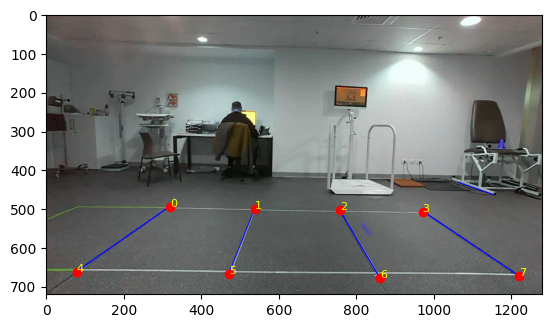

In [10]:
## Side view video: detect the grid corners in the first frame and visualize them
capA = cv.VideoCapture(VideoA)
retA, frameA = capA.read()

[top_row, bottom_row, debug] = detect_grid_corners(frameA)

print(f"Top row ({len(top_row)} corners):")
for c in top_row:
    print(" ", c)

print(f"Bottom row ({len(bottom_row)} corners):")
for c in bottom_row:
    print(" ", c)

plt.imshow(debug['vis'])

side_view = []
for r in top_row:
        side_view.append([r[0], r[1]])
        
for r in bottom_row:
        side_view.append([r[0], r[1]])

for r in range(len(side_view)):
    plt.plot(side_view[r][0], side_view[r][1], marker='o', color='red')
    plt.text(side_view[r][0], side_view[r][1], f"{r}", color='yellow', fontsize=8)

      
print(side_view)
# if retA == True:
#     greyFrameA = cv.cvtColor(frameA, cv.COLOR_BGR2GRAY) 
#     #gray = np.float32(greyFrameA)
#     edges = cv.Canny(greyFrameA,200,550,apertureSize=3)
#     # Creating kernel
#     kernel = np.ones((5, 5), np.uint8)
#     edges = cv.dilate(edges,kernel)
#     lines = cv.HoughLinesP(
#             edges, # Input edge image
#         3, # Distance resolution in pixels
#             np.pi/180, # Angle resolution in radians
#             threshold=300, # Min number of votes for valid line
#             minLineLength=150, # Min allowed length of line
#             maxLineGap=6 # Max allowed gap between line for joining them
#             )

#     #plt.imshow(edges)
#     line_l=draw_lines(lines,frameA)
#     #plt.imshow(line_l)
#     line_l=cv.cvtColor(line_l, cv.COLOR_BGR2GRAY)
#     dst = cv.cornerHarris(line_l,20,3,0.04)
#     dst = cv.dilate(dst,None)
#     #plt.imshow(dst)
#     #plt.colorbar()
#     ret, dst = cv.threshold(dst,0.2*dst.max(),255,0)
#     dst = np.uint8(dst)
#     # find centroids
#     retA1, labels, stats, centroids = cv.connectedComponentsWithStats(dst)
 
#     # define the criteria to stop and refine the corners
#     criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 100, 0.0001)
#     corners = cv.cornerSubPix(line_l,np.float32(centroids[1:]),(5,5),(-1,-1),criteria)

#     # To draw the corners
#     plt.imshow(greyFrameA)
#     for corner in corners:
#         plt.plot(corner[0],corner[1],marker='o')
#         #frameA[int(corner[1]), int(corner[0])] = [0, 0, 255]
    
#     int_corners = np.asarray(corners, dtype = int)


capA.release()
cv.destroyAllWindows()

#print(int_corners)

In [11]:
def detect_corners_frontal(img, roi=None, tophat_kernel=15,
                         min_component_area=100, min_line_length=30,
                         max_line_gap=20, hough_threshold=25,
                         angle_split_deg=20, angle_merge_deg=8,
                         dist_merge_px=15, min_merged_line_length=60,
                         max_corner_dist_from_mask=20, roi_polygon=None,
                         expected_rungs=None, search_extra='far',
                         band_half_height=30, band_margin=15):
    """
    Detect corners formed by two 'rail' lines (running away from the
    camera) crossed by several short 'rung' lines at different depths -
    e.g. a walking lane filmed roughly along its length.

    Primary pass: strict thresholds, split segments into 'shallow'
    (rungs) vs 'steep' (rails) by angle, merge fragments into one line
    per physical rail/rung, and intersect only ACROSS the two groups
    (never within a group - this is what keeps false corners out).

    Fallback pass (new): if expected_rungs is given and fewer rungs were
    found than expected (e.g. a rung is faint or occluded by a person
    standing on it), estimate where the missing rung should be by
    extrapolating the spacing pattern of the rungs that WERE found along
    each rail (spacing shrinks with distance due to perspective, so this
    uses a geometric-ratio extrapolation rather than a fixed step), then
    re-runs detection with loosened thresholds restricted to a small
    search band around that estimate only. Restricting the search area
    keeps this safe to loosen - the risk of picking up unrelated clutter
    (e.g. part of a person's body) as a false line is low when only a
    thin strip of the image is being searched. If nothing is found even
    there, the pure extrapolated point is returned as a lower-confidence
    estimate rather than a direct detection, and flagged as such.

    Parameters
    ----------
    roi : (x0, y0, x1, y1) or None
        Pixel region to search within. Defaults to the full image.
    roi_polygon : list of (x,y) or None
        Extra region to blank out (e.g. a person occluding part of a line).
    expected_rungs : int or None
        Total number of rungs the lane is known to have. If more are
        expected than found, the fallback search kicks in.
    search_extra : 'far' | 'near' | 'both'
        Which end(s) of the rail to extrapolate beyond when looking for
        missing rungs. 'far' = beyond the smallest-y (most distant) rung
        found, which is the common case for a rung occluded by someone
        standing near the far end of the lane.
    band_half_height, band_margin : int
        Size of the restricted search band used in the fallback pass.

    Returns
    -------
    rows : list of dicts, ordered far-to-near (ascending y), each with
        keys 'left' (x,y), 'right' (x,y), 'y', 'source' - source is one
        of 'detected' (found in the primary pass), 'recovered' (found in
        the targeted fallback pass) or 'estimated' (no direct visual
        evidence, pure extrapolation from rail geometry - treat with
        more caution).
    debug : dict with 'mask', 'vis', 'shallow_lines', 'steep_lines',
        'rails' for inspection/tuning.
    """

    shallow, steep, mask, (x0, y0, x1, y1) = _detect_line_groups(
        img, roi, tophat_kernel, min_component_area, min_line_length,
        max_line_gap, hough_threshold, angle_split_deg, angle_merge_deg,
        dist_merge_px, min_merged_line_length, roi_polygon)

    debug = {"mask": mask, "vis": img.copy(),
             "shallow_lines": [(a+x0, b+y0, c+x0, d+y0) for a, b, c, d in shallow],
             "steep_lines": [(a+x0, b+y0, c+x0, d+y0) for a, b, c, d in steep],
             "rails": []}

    if len(steep) < 2:
        print(f"Warning: only found {len(steep)} rail(s), need 2. "
              f"Try adjusting roi / thresholds.")
        return [], debug

    # the two rails are the two longest steep lines
    steep_full = debug["steep_lines"]
    steep_full.sort(key=lambda l: np.hypot(l[2]-l[0], l[3]-l[1]), reverse=True)
    rail1, rail2 = steep_full[0], steep_full[1]
    debug["rails"] = [rail1, rail2]

    def x_on_rail(rail, y):
        ax, ay, bx, by = rail
        if by == ay:
            return ax
        return ax + (bx - ax) * (y - ay) / (by - ay)

    # --- primary pass: intersect each rung with both rails ---
    rows = []
    for (a, b, c, d) in debug["shallow_lines"]:
        p1 = _line_intersection((a, b, c, d), rail1)
        p2 = _line_intersection((a, b, c, d), rail2)
        if p1 is None or p2 is None:
            continue
        if (_dist_to_nearest_maskpoint(mask, p1[0]-x0, p1[1]-y0) > max_corner_dist_from_mask or
                _dist_to_nearest_maskpoint(mask, p2[0]-x0, p2[1]-y0) > max_corner_dist_from_mask):
            continue
        left, right = sorted([p1, p2], key=lambda p: p[0])
        rows.append({"left": left, "right": right, "y": (left[1]+right[1])/2,
                      "source": "detected"})
    print(rows)
    rows = _dedupe_rows(rows, min_dist=15)
    rows.sort(key=lambda r: r["y"])

    # --- fallback: try to recover missing rungs ---
    if expected_rungs is not None and len(rows) < expected_rungs and len(rows) >= 2:
        missing = expected_rungs - len(rows)
        sides = []
        if search_extra in ("far", "both"):
            sides.append("far")
        if search_extra in ("near", "both"):
            sides.append("near")

        for i in range(missing):
            if not sides:
                break
            side = sides[i % len(sides)] if search_extra == "both" else sides[0]
            ys = [r["y"] for r in rows]
            gaps = [ys[j+1] - ys[j] for j in range(len(ys)-1)]

            if side == "far":
                ratio = (gaps[0] / gaps[1]) if len(gaps) >= 2 and gaps[1] != 0 else 1.0
                y_est = ys[0] - gaps[0] * ratio
            else:
                ratio = (gaps[-1] / gaps[-2]) if len(gaps) >= 2 and gaps[-2] != 0 else 1.0
                y_est = ys[-1] + gaps[-1] * ratio

            recovered = _targeted_rescan(img, rail1, rail2, x_on_rail, y_est,
                                          band_half_height, band_margin,
                                          tophat_kernel, angle_split_deg,
                                          angle_merge_deg, dist_merge_px)
            if recovered is not None:
                rows.append(recovered)
            else:
                lx, rx = x_on_rail(rail1, y_est), x_on_rail(rail2, y_est)
                left, right = sorted([(lx, y_est), (rx, y_est)], key=lambda p: p[0])
                rows.append({"left": left, "right": right, "y": y_est,
                              "source": "estimated"})
            rows.sort(key=lambda r: r["y"])

    # --- debug visualization ---
    vis = img.copy()
    for (a, b, c, d) in [rail1, rail2]:
        cv.line(vis, (a, b), (c, d), (0, 0, 255), 2)
    color_by_source = {"detected": (0, 255, 0), "recovered": (0, 255, 255),
                        "estimated": (0, 165, 255)}
    for r in rows:
        for pt in (r["left"], r["right"]):
            cv.circle(vis, (int(pt[0]), int(pt[1])), 8,
                       color_by_source[r["source"]], -1)
    debug["vis"] = vis

    return rows, debug


def _detect_line_groups(img, roi, tophat_kernel, min_component_area,
                         min_line_length, max_line_gap, hough_threshold,
                         angle_split_deg, angle_merge_deg, dist_merge_px,
                         min_merged_line_length, roi_polygon):
    h, w = img.shape[:2]
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    if roi is None:
        x0, y0, x1, y1 = 0, 0, w, h
    else:
        x0, y0, x1, y1 = roi
    crop = gray[y0:y1, x0:x1]


    kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (tophat_kernel, tophat_kernel))
    tophat = cv.morphologyEx(crop, cv.MORPH_TOPHAT, kernel)
    _, mask = cv.threshold(tophat, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

    if roi_polygon is not None:
        poly_mask = np.zeros_like(crop, dtype=np.uint8)
        cv.fillPoly(poly_mask, [np.array(roi_polygon, dtype=np.int32) - [x0, y0]], 255)
        mask[poly_mask > 0] = 0

    n_comp, labels, stats, _ = cv.connectedComponentsWithStats(mask, connectivity=8)
    clean = np.zeros_like(mask)
    for i in range(1, n_comp):
        if stats[i, cv.CC_STAT_AREA] >= min_component_area:
            clean[labels == i] = 255
    mask = clean

    k2 = cv.getStructuringElement(cv.MORPH_ELLIPSE, (3, 3))
    mask_d = cv.dilate(mask, k2, iterations=1)
    mask_c = cv.morphologyEx(mask_d, cv.MORPH_CLOSE,
                               cv.getStructuringElement(cv.MORPH_ELLIPSE, (9, 9)))

    edges = cv.Canny(mask_c, 50, 150)
    raw_lines = cv.HoughLinesP(edges, 1, np.pi / 180, threshold=hough_threshold,
                                 minLineLength=min_line_length, maxLineGap=max_line_gap)

    if raw_lines is None:
        return [], [], mask_c, (x0, y0, x1, y1)

    shallow, steep = [], []
    for l in raw_lines:
        x1_, y1_, x2_, y2_ = l[0]
        ang = np.degrees(np.arctan2(y2_ - y1_, x2_ - x1_))
        (shallow if abs(ang) < angle_split_deg else steep).append((x1_, y1_, x2_, y2_))

    shallow = _merge_lines(shallow, angle_merge_deg, dist_merge_px)
    steep = _merge_lines(steep, angle_merge_deg, dist_merge_px)
    shallow = [l for l in shallow if np.hypot(l[2]-l[0], l[3]-l[1]) >= min_merged_line_length]
    steep = [l for l in steep if np.hypot(l[2]-l[0], l[3]-l[1]) >= min_merged_line_length]

    return shallow, steep, mask_c, (x0, y0, x1, y1)


def _targeted_rescan(img, rail1, rail2, x_on_rail, y_est, band_half_height,
                      band_margin, tophat_kernel, angle_split_deg,
                      angle_merge_deg, dist_merge_px):
    """Loosened, spatially-restricted search for one missing rung."""
    lx, rx = x_on_rail(rail1, y_est), x_on_rail(rail2, y_est)
    x_lo, x_hi = sorted([lx, rx])
    roi = (int(x_lo - band_margin), int(y_est - band_half_height),
           int(x_hi + band_margin), int(y_est + band_half_height))
    roi = (max(0, roi[0]), max(0, roi[1]),
           min(img.shape[1], roi[2]), min(img.shape[0], roi[3]))
    if roi[2] <= roi[0] or roi[3] <= roi[1]:
        return None

    shallow, _, mask, (x0, y0, _, _) = _detect_line_groups(
        img, roi, tophat_kernel, min_component_area=25, min_line_length=15,
        max_line_gap=25, hough_threshold=12, angle_split_deg=angle_split_deg,
        angle_merge_deg=angle_merge_deg, dist_merge_px=dist_merge_px,
        min_merged_line_length=20, roi_polygon=None)

    if not shallow:
        return None

    # pick the longest candidate found in the band
    best = max(shallow, key=lambda l: np.hypot(l[2]-l[0], l[3]-l[1]))
    best_full = (best[0]+x0, best[1]+y0, best[2]+x0, best[3]+y0)
    p1 = _line_intersection(best_full, rail1)
    p2 = _line_intersection(best_full, rail2)
    if p1 is None or p2 is None:
        return None
    left, right = sorted([p1, p2], key=lambda p: p[0])
    return {"left": left, "right": right, "y": (left[1]+right[1])/2, "source": "recovered"}


def _merge_lines(segments, angle_merge_deg, dist_merge_px):
    def line_params(seg):
        x1, y1, x2, y2 = seg
        angle = np.degrees(np.arctan2(y2 - y1, x2 - x1)) % 180
        theta = np.radians(angle)
        rho = x1 * np.sin(theta) - y1 * np.cos(theta)
        return angle, rho

    groups = []
    for seg in segments:
        angle, rho = line_params(seg)
        placed = False
        for g in groups:
            d_angle = min(abs(angle - g["angle"]), 180 - abs(angle - g["angle"]))
            if d_angle <= angle_merge_deg and abs(rho - g["rho"]) <= dist_merge_px:
                g["segs"].append(seg)
                placed = True
                break
        if not placed:
            groups.append({"angle": angle, "rho": rho, "segs": [seg]})

    merged = []
    for g in groups:
        pts = np.array([[s[0], s[1]] for s in g["segs"]] +
                        [[s[2], s[3]] for s in g["segs"]], dtype=np.float32)
        vx, vy, x0_, y0_ = cv.fitLine(pts, cv.DIST_L2, 0, 0.01, 0.01).flatten()
        t = np.dot(pts - [x0_, y0_], [[vx], [vy]])
        t_min, t_max = t.min(), t.max()
        p1 = (x0_ + vx * t_min, y0_ + vy * t_min)
        p2 = (x0_ + vx * t_max, y0_ + vy * t_max)
        merged.append((int(p1[0]), int(p1[1]), int(p2[0]), int(p2[1])))
    return merged


def _line_intersection(l1, l2):
    x1, y1, x2, y2 = l1
    x3, y3, x4, y4 = l2
    denom = (x1 - x2) * (y3 - y4) - (y1 - y2) * (x3 - x4)
    if abs(denom) < 1e-6:
        return None
    px = ((x1*y2 - y1*x2)*(x3-x4) - (x1-x2)*(x3*y4 - y3*x4)) / denom
    py = ((x1*y2 - y1*x2)*(y3-y4) - (y1-y2)*(x3*y4 - y3*x4)) / denom
    return px, py

def _dedupe_rows(rows, min_dist=15):
    kept = []
    for r in rows:
        if all(abs(r["y"] - k["y"]) > min_dist for k in kept):
            kept.append(r)
    return kept

def _dist_to_nearest_maskpoint(mask, x, y, search_radius=40):
    x, y = int(round(x)), int(round(y))
    h, w = mask.shape
    xa, xb = max(0, x - search_radius), min(w, x + search_radius)
    ya, yb = max(0, y - search_radius), min(h, y + search_radius)
    patch = mask[ya:yb, xa:xb]
    ys, xs = np.where(patch > 0)
    if len(xs) == 0:
        return np.inf
    d = np.sqrt((xs + xa - x) ** 2 + (ys + ya - y) ** 2)
    return d.min()



[{'left': (463.828616938106, 689.2379605883256), 'right': (929.5780874301109, 712.1907065673977), 'y': 700.7143335778617, 'source': 'detected'}, {'left': (584.5661183402897, 487.02116376135524), 'right': (798.6480686695279, 489.91416309012874), 'y': 488.467663425742, 'source': 'detected'}, {'left': (546.7291623790903, 550.3922617822598), 'right': (839.1942675159236, 558.7484076433121), 'y': 554.570334712786, 'source': 'detected'}]
  [ recovered] left=(606.07326007326, 451.0), right=(775.7260273972603, 451.0)
  [  detected] left=(584.5661183402897, 487.02116376135524), right=(798.6480686695279, 489.91416309012874)
  [  detected] left=(546.7291623790903, 550.3922617822598), right=(839.1942675159236, 558.7484076433121)
  [  detected] left=(463.828616938106, 689.2379605883256), right=(929.5780874301109, 712.1907065673977)
[{'left': (606.07326007326, 451.0), 'right': (775.7260273972603, 451.0), 'y': 451.0, 'source': 'recovered'}, {'left': (584.5661183402897, 487.02116376135524), 'right': (7

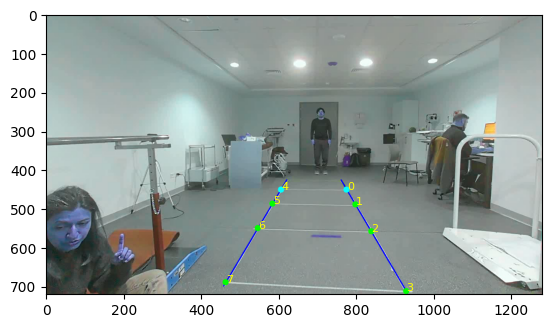

In [12]:
## Side view video: detect the grid corners in the first frame and visualize them
capB = cv.VideoCapture(VideoB)
retB, frameB = capB.read()

[rows, debug] = detect_corners_frontal(frameB,roi=(350, 400, 1000, 720), expected_rungs=4,hough_threshold=25)

for r in rows:
        print(f"  [{r['source']:>10}] left={r['left']}, right={r['right']}")


plt.imshow(debug['vis'])
counter=1
print(rows)
frontal_view = []
for r in rows:
        frontal_view.append([r['right'][0], r['right'][1]])

for r in rows:
        frontal_view.append([r['left'][0], r['left'][1]])

for r in range(len(frontal_view)):
       
        plt.text(frontal_view[r][0],frontal_view[r][1], f"{r}", color='yellow', fontsize=8)
        print(frontal_view[r][0],frontal_view[r][1])

capB.release()
cv.destroyAllWindows()


## Obj: convert the points from both cameras to 3d points

Plane equation: 0.0113x + -0.9980y + -0.0615z = -1037.3515
Centroid: [ -61.59617865  878.63455796 2598.71315037]
Normal (orthogonal axis): [ 0.01128601 -0.99804521 -0.06146861]
RMS fit error: 19.9648
Max abs residual: 33.8862


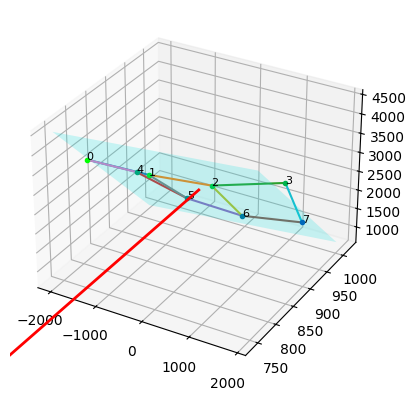

In [13]:
Calib_n = '17'
Calib_video = './Calibration_Videos_RS/Calibration_parameters_'+Calib_n+'.npz'
npz = np.load(Calib_video)

P1=npz['P1']
P2=npz['P2']

Floor3D=[]
    
for i in range(0,len(side_view)):
    D3Point = DLT(P1,P2,side_view[i], frontal_view[i])
    Floor3D.append(D3Point)

## now plot    
fig2 = plt.figure()
ax = fig2.add_subplot(111, projection='3d')

# Floor
connections = [[0,1], [1,2],[2,3], [4,5], [5,6], [6,7],[0,4],[1,5],[2,6],[3,7]]
for _c in connections:
      ax.plot(xs = [Floor3D[_c[0]][0], Floor3D[_c[1]][0]], ys = [Floor3D[_c[0]][1], Floor3D[_c[1]][1]], zs = [Floor3D[_c[0]][2], Floor3D[_c[1]][2]])
     
for i in range(0,len(Floor3D)):        
        ax.plot(Floor3D[i][0], Floor3D[i][1],Floor3D[i][2],'.',color = [0,1-i*0.1,i*0.1])
        ax.text(Floor3D[i][0], Floor3D[i][1],Floor3D[i][2], f"{i}", color='black', fontsize=8)

## fit a plane to the 3D points
centroid, normal = fit_plane(Floor3D)

a, b, c = normal
d = np.dot(normal, centroid)
print(f"Plane equation: {a:.4f}x + {b:.4f}y + {c:.4f}z = {d:.4f}")
print(f"Centroid: {centroid}")
print(f"Normal (orthogonal axis): {normal}")

# fit quality: perpendicular distance of each point from the plane
residuals = (np.asarray(Floor3D) - centroid) @ normal
print(f"RMS fit error: {np.sqrt(np.mean(residuals**2)):.4f}")
print(f"Max abs residual: {np.max(np.abs(residuals)):.4f}")


## visualise 3D plane
# --- visualize the fitted plane and its normal ---
arbitrary = np.array([1, 0, 0]) if abs(normal[0]) < 0.9 else np.array([0, 1, 0])
u = np.cross(normal, arbitrary); 
u /= np.linalg.norm(u)
v = np.cross(normal, u)

size = np.linalg.norm(np.asarray(Floor3D).max(axis=0) - np.asarray(Floor3D).min(axis=0)) / 2
grid = np.linspace(-size, size, 2)
uu, vv = np.meshgrid(grid, grid)
plane_pts = centroid + uu[..., None]*u + vv[..., None]*v
ax.plot_surface(plane_pts[..., 0], plane_pts[..., 1], plane_pts[..., 2], alpha=0.2, color='cyan')

# normal vector, drawn from the centroid
ax.quiver(*centroid, *(normal * size * 0.5), color='red', linewidth=2)



Point 0 in the new frame (should be exactly [0, 0, 0]):
[0. 0. 0.]
Custom-frame Z values (should be ~0 for your calibration corners,
since Z is now the out-of-plane axis):
[  0.           4.52202776  -1.68492436 -44.75772287 -44.424165
  -4.53595769   9.23416048  -5.3257885 ]


(-10.0, 1700.0)

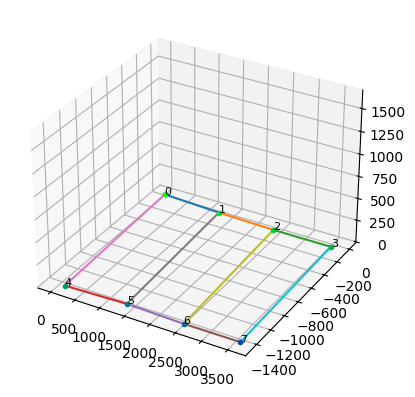

In [14]:
# --- usage ---
RotatedFloor, R, origin = transform_to_custom_frame(
    Floor3D, centroid, normal,
    x_from=Floor3D[0], x_to=Floor3D[3],
    origin=Floor3D[0],
)


np.savez('./Calibration_Videos_RS/Floor_parameters_'+str(Nvideo), Floor3D=Floor3D, RotatedFloor=RotatedFloor, centroid=centroid, normal=normal, R=R, origin=origin)

print("Point 0 in the new frame (should be exactly [0, 0, 0]):")
print(RotatedFloor[0])
print("Custom-frame Z values (should be ~0 for your calibration corners,")
print("since Z is now the out-of-plane axis):")
print(RotatedFloor[:, 2])


## now plot    
fig2 = plt.figure()
ax = fig2.add_subplot(111, projection='3d')

# Floor in real world coordinates
for _c in connections:
      ax.plot(xs = [RotatedFloor[_c[0],0], RotatedFloor[_c[1],0]], ys = [RotatedFloor[_c[0],1], RotatedFloor[_c[1],1]], zs = [RotatedFloor[_c[0],2], RotatedFloor[_c[1],2]])
     
for i in range(0,len(Floor3D)):        
        ax.plot(RotatedFloor[i,0], RotatedFloor[i,1],RotatedFloor[i,2],'.',color = [0,1-i*0.1,i*0.1])
        ax.text(RotatedFloor[i,0], RotatedFloor[i,1],RotatedFloor[i,2], f"{i}", color='black', fontsize=8)

ax.set_zlim3d([-10, 1700])
